# Beyond Mass: Did BIND Learn Physics or Just Mass Assignment?

This notebook is designed to break the circularity in mass-derived diagnostics.

If total enclosed mass is already correct, then many scalar metrics follow automatically. To test whether BIND learned *more than* a mass-conditioned lookup, we evaluate:

1. **Radial profile shape at fixed halo mass** (spatial redistribution).
2. **Cross-channel spatial covariance** via cross-power/correlation spectra (field-level structure).
3. **Parameter response of profile shape** (AGN-driven redistribution vs pure normalization changes).
4. **SHMR scatter conditioned on morphology** (assembly-bias-like information beyond mass).

Then we run the requested BIND fidelity diagnostics:

1. Per-halo residual correlation $\rho(z_{\rm truth}, z_{\rm BIND})$.
2. Outlier identity preservation at $|z|\ge 3$ (precision/recall/F1/Jaccard).
3. Joint cross-observable signature for **BIND baryon outliers** (gas/DM vs star/concentration pattern).

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import binned_statistic, spearmanr, pearsonr
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=ConvergenceWarning)

try:
    import scienceplots
    plt.style.use(['science', 'notebook'])
except Exception:
    pass

plt.rcParams.update({
    'font.size': 10,
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# Paths and constants
SUITE_ROOT = Path('/mnt/home/mlee1/ceph/fm_testsuite')
SNAP = 'snap_090'
MASS_TAG = 'mass_threshold_1p000e13'
MODEL_NAME = 'fm_two_head'

BOX_SIZE = 50.0
N_PIX_FULL = 1024
PATCH_PIX = 128
PATCH_BOX = BOX_SIZE * PATCH_PIX / N_PIX_FULL
MPC_PER_PIX = PATCH_BOX / PATCH_PIX

FIG_DIR = Path('paper_figures')
FIG_DIR.mkdir(exist_ok=True)
CACHE_DIR = Path('analysis_physics_cache')
CACHE_DIR.mkdir(exist_ok=True)


def save_fig(fig, name, ext=('pdf', 'png')):
    for e in ext:
        out = FIG_DIR / f'{name}.{e}'
        fig.savefig(out)
        print(f'  wrote {out}')

print('Setup complete.')

Setup complete.


In [2]:
def sim_record(sim_dir: Path, suite_name: str) -> dict:
    snap = sim_dir / SNAP
    mass = snap / MASS_TAG
    model = mass / MODEL_NAME
    rec = {
        'suite': suite_name,
        'sim_id': sim_dir.name,
        'sim_dir': sim_dir,
        'full_maps': snap / 'full_maps.npz',
        'halo_catalog': mass / 'halo_catalog.npz',
        'cutouts': mass / 'halo_cutouts.npz',
        'generated': model / 'generated_halos.npz',
    }
    rec['available'] = all(rec[k].exists() for k in ('full_maps', 'halo_catalog', 'cutouts', 'generated'))
    return rec


def discover_sims(suites=('CV', '1P', 'Test')) -> pd.DataFrame:
    recs = []
    for suite in suites:
        root = SUITE_ROOT / suite
        if not root.exists():
            continue
        for sd in sorted(root.iterdir()):
            if sd.is_dir():
                recs.append(sim_record(sd, suite))
    return pd.DataFrame(recs)


sims_all = discover_sims()
sims = sims_all[sims_all['available']].reset_index(drop=True)
cv_sims = sims[sims['suite'] == 'CV'].reset_index(drop=True)

cache_file = CACHE_DIR / f'obs_{MODEL_NAME}.npz'
if not cache_file.exists():
    raise FileNotFoundError(f'Missing scalar observable cache: {cache_file}')

cache = np.load(cache_file, allow_pickle=True)
N_PARAMS = int(cache['params'].shape[1])


def build_obs_df(cache_obj) -> pd.DataFrame:
    df = pd.DataFrame({
        'suite': cache_obj['suite'].astype(str),
        'sim_id': cache_obj['sim_id'].astype(str),
        'logM': cache_obj['logM'].astype(np.float64),
    })
    for j in range(N_PARAMS):
        df[f'p{j+1}'] = cache_obj['params'][:, j]

    obs_keys = ['M_dm', 'M_gas', 'M_star', 'f_b', 'f_b_norm', 'Rc_over_R200', 'q_DM', 'q_gas', 'q_star', 'dq_DM', 'Sigma_gas_c']
    for k in obs_keys:
        df[f'truth_{k}'] = cache_obj[f'truth_{k}'].astype(np.float64)
        df[f'gen_{k}'] = cache_obj[f'gen_{k}'].astype(np.float64)
    return df


obs_df = build_obs_df(cache)
cv_df = obs_df[obs_df['suite'] == 'CV'].copy().reset_index(drop=True)
cv_df['halo_in_sim'] = cv_df.groupby('sim_id').cumcount()

print(f'Loaded obs_df: {obs_df.shape}')
print(f'CV sims available: {len(cv_sims)}')
print(f'CV halos available: {len(cv_df)}')

Loaded obs_df: (12249, 60)
CV sims available: 27
CV halos available: 1154


In [3]:
# Geometry helpers
RHO_CRIT = 2.775e11

_yy, _xx = (np.mgrid[:PATCH_PIX, :PATCH_PIX] - np.array([PATCH_PIX / 2, PATCH_PIX / 2])[:, None, None])
_RR_PIX = np.sqrt(_xx ** 2 + _yy ** 2)


def _extract_patch(field_2d, cx, cy, size=PATCH_PIX):
    n = field_2d.shape[0]
    half = size // 2
    ix = (cx - half + np.arange(size)) % n
    iy = (cy - half + np.arange(size)) % n
    return field_2d[np.ix_(ix, iy)]


def _centers_to_pixels(centers_mpc):
    ppm = N_PIX_FULL / BOX_SIZE
    return (np.asarray(centers_mpc) * ppm).astype(np.int64) % N_PIX_FULL


def r200c_pix(m200c_msunh):
    r_mpc = (3.0 * m200c_msunh / (4.0 * np.pi * 200.0 * RHO_CRIT)) ** (1.0 / 3.0)
    return r_mpc / MPC_PER_PIX


def aperture_sum(field_2d, r_pix):
    return float(np.maximum(field_2d, 0.0)[_RR_PIX < r_pix].sum())


def mass_fraction_profile(field_2d, r_aper_pix, edges_scaled):
    f = np.maximum(field_2d, 0.0)
    rr_s = _RR_PIX / max(r_aper_pix, 1e-8)
    ann_mass = np.zeros(len(edges_scaled) - 1, dtype=np.float64)
    for i, (lo, hi) in enumerate(zip(edges_scaled[:-1], edges_scaled[1:])):
        ann_mass[i] = f[(rr_s >= lo) & (rr_s < hi)].sum()
    mtot = ann_mass.sum()
    if mtot <= 0:
        return np.full_like(ann_mass, np.nan)
    return ann_mass / mtot


def profile_slope(profile_frac, edges_scaled, r_lo=0.2, r_hi=0.8):
    rc = 0.5 * (edges_scaled[:-1] + edges_scaled[1:])
    ok = (
        np.isfinite(profile_frac)
        & (profile_frac > 0)
        & np.isfinite(rc)
        & (rc >= r_lo)
        & (rc <= r_hi)
    )
    if ok.sum() < 4:
        return np.nan
    x = np.log10(rc[ok])
    y = np.log10(profile_frac[ok])
    return float(np.polyfit(x, y, 1)[0])


def isotropic_cross_corr_coeff(a2d, b2d, n_k=24):
    a = a2d.astype(np.float64) - np.nanmean(a2d)
    b = b2d.astype(np.float64) - np.nanmean(b2d)
    fa = np.fft.fft2(a)
    fb = np.fft.fft2(b)

    p11 = np.abs(fa) ** 2
    p22 = np.abs(fb) ** 2
    p12 = np.real(fa * np.conj(fb))

    n = a.shape[0]
    kfreq = np.fft.fftfreq(n) * n
    kx, ky = np.meshgrid(kfreq, kfreq, indexing='ij')
    kk = np.sqrt(kx ** 2 + ky ** 2).ravel()

    edges = np.linspace(0, kk.max(), n_k + 1)
    kc = 0.5 * (edges[:-1] + edges[1:])
    rcorr = np.full(n_k, np.nan, dtype=np.float64)

    p11f = p11.ravel()
    p22f = p22.ravel()
    p12f = p12.ravel()

    for i in range(n_k):
        m = (kk >= edges[i]) & (kk < edges[i + 1])
        if m.sum() < 10:
            continue
        p11m = p11f[m].mean()
        p22m = p22f[m].mean()
        p12m = p12f[m].mean()
        denom = np.sqrt(max(p11m, 1e-30) * max(p22m, 1e-30))
        rcorr[i] = p12m / denom

    return kc, rcorr


def gp_zscore(x, y, n_restarts=4):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    ok = np.isfinite(x) & np.isfinite(y)
    idx_ok = np.where(ok)[0]
    xv = x[ok]
    yv = y[ok]

    if len(xv) < 50:
        raise RuntimeError(f'Too few finite points for GP fit: {len(xv)}')

    x_mu = np.mean(xv)
    x_sig = np.std(xv)
    if (not np.isfinite(x_sig)) or (x_sig <= 0):
        raise RuntimeError('Invalid mass-axis spread for GP fit.')

    X = ((xv - x_mu) / x_sig).reshape(-1, 1)
    kernel = (
        ConstantKernel(0.5, (1e-3, 20.0))
        * RBF(length_scale=1.0, length_scale_bounds=(5e-2, 10.0))
        + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-6, 1.0))
    )
    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=1e-6,
        normalize_y=True,
        n_restarts_optimizer=n_restarts,
        random_state=0,
    )
    gp.fit(X, yv)

    mu, std = gp.predict(X, return_std=True)
    std_eff = np.maximum(std, 1e-6)
    z = (yv - mu) / std_eff

    z_full = np.full(len(x), np.nan)
    mu_full = np.full(len(x), np.nan)
    std_full = np.full(len(x), np.nan)
    out_full = np.zeros(len(x), dtype=bool)

    z_full[idx_ok] = z
    mu_full[idx_ok] = mu
    std_full[idx_ok] = std_eff
    out_full[idx_ok] = np.abs(z) >= 3.0

    return {
        'gp': gp,
        'x_mu': x_mu,
        'x_sig': x_sig,
        'idx_ok': idx_ok,
        'z_full': z_full,
        'mu_full': mu_full,
        'std_full': std_full,
        'out_full': out_full,
        'mask': ok,
    }


def gp_curve_from_fit(gp_fit, x_ref, n_grid=400):
    x_ref = np.asarray(x_ref, dtype=np.float64)
    x_ok = x_ref[np.isfinite(x_ref)]
    xg = np.linspace(np.min(x_ok), np.max(x_ok), n_grid)
    Xg = ((xg - gp_fit['x_mu']) / gp_fit['x_sig']).reshape(-1, 1)
    mu, std = gp_fit['gp'].predict(Xg, return_std=True)
    return xg, mu, np.maximum(std, 1e-6)


def partial_spearman(x, y, z):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    z = np.asarray(z, dtype=np.float64)
    ok = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
    if ok.sum() < 30:
        return np.nan, np.nan

    def _rank_resid(a, b):
        ra = pd.Series(a).rank().to_numpy(dtype=np.float64)
        rb = pd.Series(b).rank().to_numpy(dtype=np.float64)
        ra = ra - ra.mean()
        rb = rb - rb.mean()
        bb = float((rb * rb).sum())
        if bb <= 0:
            return ra
        return ra - (float((ra * rb).sum()) / bb) * rb

    rx = _rank_resid(x[ok], z[ok])
    ry = _rank_resid(y[ok], z[ok])
    return pearsonr(rx, ry)


print('Helper functions ready.')

Helper functions ready.


In [11]:
FIELD_CACHE = CACHE_DIR / 'beyond_mass_cv_field_cache_rmax140_v2.npz'
PROFILE_EDGES = np.linspace(0.0, 1.40, 29)  # 28 annuli, extends beyond R200
N_K = 24


def build_field_cache(cv_df, cv_sims, force=False):
    if FIELD_CACHE.exists() and not force:
        z = np.load(FIELD_CACHE, allow_pickle=True)
        print(f'Loaded field cache: {FIELD_CACHE}')
        return {k: z[k] for k in z.files}

    N = len(cv_df)
    n_prof = len(PROFILE_EDGES) - 1

    gas_prof_truth = np.full((N, n_prof), np.nan, dtype=np.float64)
    gas_prof_bind = np.full((N, n_prof), np.nan, dtype=np.float64)

    c_dm_truth = np.full(N, np.nan, dtype=np.float64)
    c_dm_bind = np.full(N, np.nan, dtype=np.float64)
    c_gas_truth = np.full(N, np.nan, dtype=np.float64)
    c_gas_bind = np.full(N, np.nan, dtype=np.float64)

    slope_gas_truth = np.full(N, np.nan, dtype=np.float64)
    slope_gas_bind = np.full(N, np.nan, dtype=np.float64)

    cross_gd_truth = np.full((N, N_K), np.nan, dtype=np.float64)
    cross_gd_bind = np.full((N, N_K), np.nan, dtype=np.float64)
    cross_sd_truth = np.full((N, N_K), np.nan, dtype=np.float64)
    cross_sd_bind = np.full((N, N_K), np.nan, dtype=np.float64)

    k_centers = None

    cv_by_sim = {sid: np.where(cv_df['sim_id'].to_numpy() == sid)[0] for sid in cv_df['sim_id'].unique()}

    for ii, rec in enumerate(cv_sims.to_dict('records')):
        sid = rec['sim_id']
        rows = cv_by_sim.get(sid, np.array([], dtype=int))
        if len(rows) == 0:
            continue

        cat = np.load(rec['halo_catalog'])
        fm = np.load(rec['full_maps'])
        gen = np.load(rec['generated'])['generated']  # (Nhalo, 3, 128, 128)

        centers_pix = _centers_to_pixels(cat['centers'])
        masses = cat['masses'].astype(np.float64)
        if 'radii' in cat.files:
            radii_pix = cat['radii'].astype(np.float64) / 1000.0 / MPC_PER_PIX
        else:
            radii_pix = np.array([r200c_pix(float(m)) for m in masses], dtype=np.float64)

        halo_idx = cv_df.loc[rows, 'halo_in_sim'].to_numpy(dtype=int)

        for row, hi in zip(rows, halo_idx):
            if hi < 0 or hi >= len(masses):
                continue

            cx, cy = centers_pix[hi]
            dm_t = _extract_patch(fm['truth_maps'][0], cx, cy)
            gas_t = _extract_patch(fm['truth_maps'][1], cx, cy)
            star_t = _extract_patch(fm['truth_maps'][2], cx, cy)

            dm_g = gen[hi, 0]
            gas_g = gen[hi, 1]
            star_g = gen[hi, 2]

            r200p = float(radii_pix[hi])
            r_aper = max(min(r200p, PATCH_PIX / 2 - 2), 4.0)
            r_inner = max(0.15 * r_aper, 2.0)

            # Extended shape-only radial distributions (annular mass fractions)
            prof_t = mass_fraction_profile(gas_t, r_aper, PROFILE_EDGES)
            prof_g = mass_fraction_profile(gas_g, r_aper, PROFILE_EDGES)
            gas_prof_truth[row] = prof_t
            gas_prof_bind[row] = prof_g

            slope_gas_truth[row] = profile_slope(prof_t, PROFILE_EDGES)
            slope_gas_bind[row] = profile_slope(prof_g, PROFILE_EDGES)

            # Concentrations (inner/total mass fraction)
            m_dm_t = aperture_sum(dm_t, r_aper)
            m_dm_g = aperture_sum(dm_g, r_aper)
            m_gas_t = aperture_sum(gas_t, r_aper)
            m_gas_g = aperture_sum(gas_g, r_aper)

            if m_dm_t > 0:
                c_dm_truth[row] = aperture_sum(dm_t, r_inner) / m_dm_t
            if m_dm_g > 0:
                c_dm_bind[row] = aperture_sum(dm_g, r_inner) / m_dm_g
            if m_gas_t > 0:
                c_gas_truth[row] = aperture_sum(gas_t, r_inner) / m_gas_t
            if m_gas_g > 0:
                c_gas_bind[row] = aperture_sum(gas_g, r_inner) / m_gas_g

            # Cross-channel spatial covariance spectra
            k_here, gd_t = isotropic_cross_corr_coeff(gas_t, dm_t, n_k=N_K)
            _, gd_g = isotropic_cross_corr_coeff(gas_g, dm_g, n_k=N_K)
            _, sd_t = isotropic_cross_corr_coeff(star_t, dm_t, n_k=N_K)
            _, sd_g = isotropic_cross_corr_coeff(star_g, dm_g, n_k=N_K)

            cross_gd_truth[row] = gd_t
            cross_gd_bind[row] = gd_g
            cross_sd_truth[row] = sd_t
            cross_sd_bind[row] = sd_g

            if k_centers is None:
                k_centers = k_here

        if (ii + 1) % 5 == 0:
            print(f'  processed {ii + 1}/{len(cv_sims)} CV sims')

    out = {
        'profile_edges': PROFILE_EDGES,
        'k_centers': k_centers,
        'gas_prof_truth': gas_prof_truth,
        'gas_prof_bind': gas_prof_bind,
        'c_dm_truth': c_dm_truth,
        'c_dm_bind': c_dm_bind,
        'c_gas_truth': c_gas_truth,
        'c_gas_bind': c_gas_bind,
        'slope_gas_truth': slope_gas_truth,
        'slope_gas_bind': slope_gas_bind,
        'cross_gd_truth': cross_gd_truth,
        'cross_gd_bind': cross_gd_bind,
        'cross_sd_truth': cross_sd_truth,
        'cross_sd_bind': cross_sd_bind,
    }

    np.savez_compressed(FIELD_CACHE, **out)
    print(f'Wrote field cache: {FIELD_CACHE}')
    return out


field_data = build_field_cache(cv_df, cv_sims, force=False)
print('Field cache ready.')

  processed 5/27 CV sims
  processed 10/27 CV sims
  processed 15/27 CV sims
  processed 20/27 CV sims
  processed 25/27 CV sims
Wrote field cache: analysis_physics_cache/beyond_mass_cv_field_cache_rmax140_v2.npz
Field cache ready.


In [21]:
# R200 provenance sanity check (CV set)
# In the profile pipeline we use halo_catalog['radii'] when available,
# otherwise we fall back to R200 derived from M200c and rho_crit.

n_total = 0
n_catalog = 0
ratio_chunks = []

cv_r200_mpc = np.full(len(cv_df), np.nan, dtype=np.float64)
cv_by_sim = {sid: np.where(cv_df['sim_id'].to_numpy() == sid)[0] for sid in cv_df['sim_id'].unique()}

for rec in cv_sims.to_dict('records'):
    cat = np.load(rec['halo_catalog'])
    m = cat['masses'].astype(np.float64)
    n_total += len(m)

    r_mass_mpc = (3.0 * m / (4.0 * np.pi * 200.0 * RHO_CRIT)) ** (1.0 / 3.0)

    if 'radii' in cat.files:
        r_cat_mpc = cat['radii'].astype(np.float64) / 1000.0  # kpc/h -> Mpc/h
        n_catalog += len(r_cat_mpc)
        ok = np.isfinite(r_cat_mpc) & np.isfinite(r_mass_mpc) & (r_cat_mpc > 0) & (r_mass_mpc > 0)
        if ok.any():
            ratio_chunks.append(r_cat_mpc[ok] / r_mass_mpc[ok])
        r_use_mpc = r_cat_mpc
    else:
        r_use_mpc = r_mass_mpc

    sid = rec['sim_id']
    rows = cv_by_sim.get(sid, np.array([], dtype=int))
    if len(rows) == 0:
        continue

    halo_idx = cv_df.loc[rows, 'halo_in_sim'].to_numpy(dtype=int)
    in_range = (halo_idx >= 0) & (halo_idx < len(r_use_mpc))
    if np.any(in_range):
        cv_r200_mpc[rows[in_range]] = r_use_mpc[halo_idx[in_range]]

n_fallback = n_total - n_catalog
print(f"R200 source usage (CV): catalog radii for {n_catalog}/{n_total} halos ({100.0 * n_catalog / max(n_total,1):.1f}%), fallback mass-derived for {n_fallback} halos.")

if ratio_chunks:
    rr = np.concatenate(ratio_chunks)
    print(
        "Catalog-vs-mass-derived R200 ratio (Mpc/h): "
        f"median={np.nanmedian(rr):.3f}, "
        f"p16={np.nanpercentile(rr, 16):.3f}, "
        f"p84={np.nanpercentile(rr, 84):.3f}."
    )

print(f"Finite CV R200 values aligned to cv_df: {np.isfinite(cv_r200_mpc).sum()}/{len(cv_r200_mpc)}")

R200 source usage (CV): catalog radii for 1111/1154 halos (96.3%), fallback mass-derived for 43 halos.
Catalog-vs-mass-derived R200 ratio (Mpc/h): median=1.000, p16=1.000, p84=1.000.
Finite CV R200 values aligned to cv_df: 1154/1154


## Test A: Radial Profile Shape at Fixed Mass (Quintiles + Residuals)

This controls for halo mass by splitting CV halos into **mass quintiles** and compares gas profiles
using annular cylindrical density
$\rho_{\rm cyl,ann}(r) = \Delta M / \left[\pi\left(r_{\rm out}^2-r_{\rm in}^2\right)z\right]$ with $z=50\,{\rm Mpc}/h$, out to **$1.4\,R_{200c}$**.

Top panels show Truth as median points with error bars and BIND as median curves with shaded error contours.
For this trial, uncertainties use the Gaussian-median approximation
$\sigma_{\rm med}\approx 1.253\,\sigma/\sqrt{231}$ separately for Truth and BIND. Bottom panels show
$(\mathrm{BIND}-\mathrm{Truth})/\mathrm{Truth}$ computed from the top medians, with uncertainty propagated
from those same top-panel median errors (independence approximation).

  wrote paper_figures/beyond_mass_testA_radial_shape_quintiles_residual.pdf
  wrote paper_figures/beyond_mass_testA_radial_shape_quintiles_residual.png


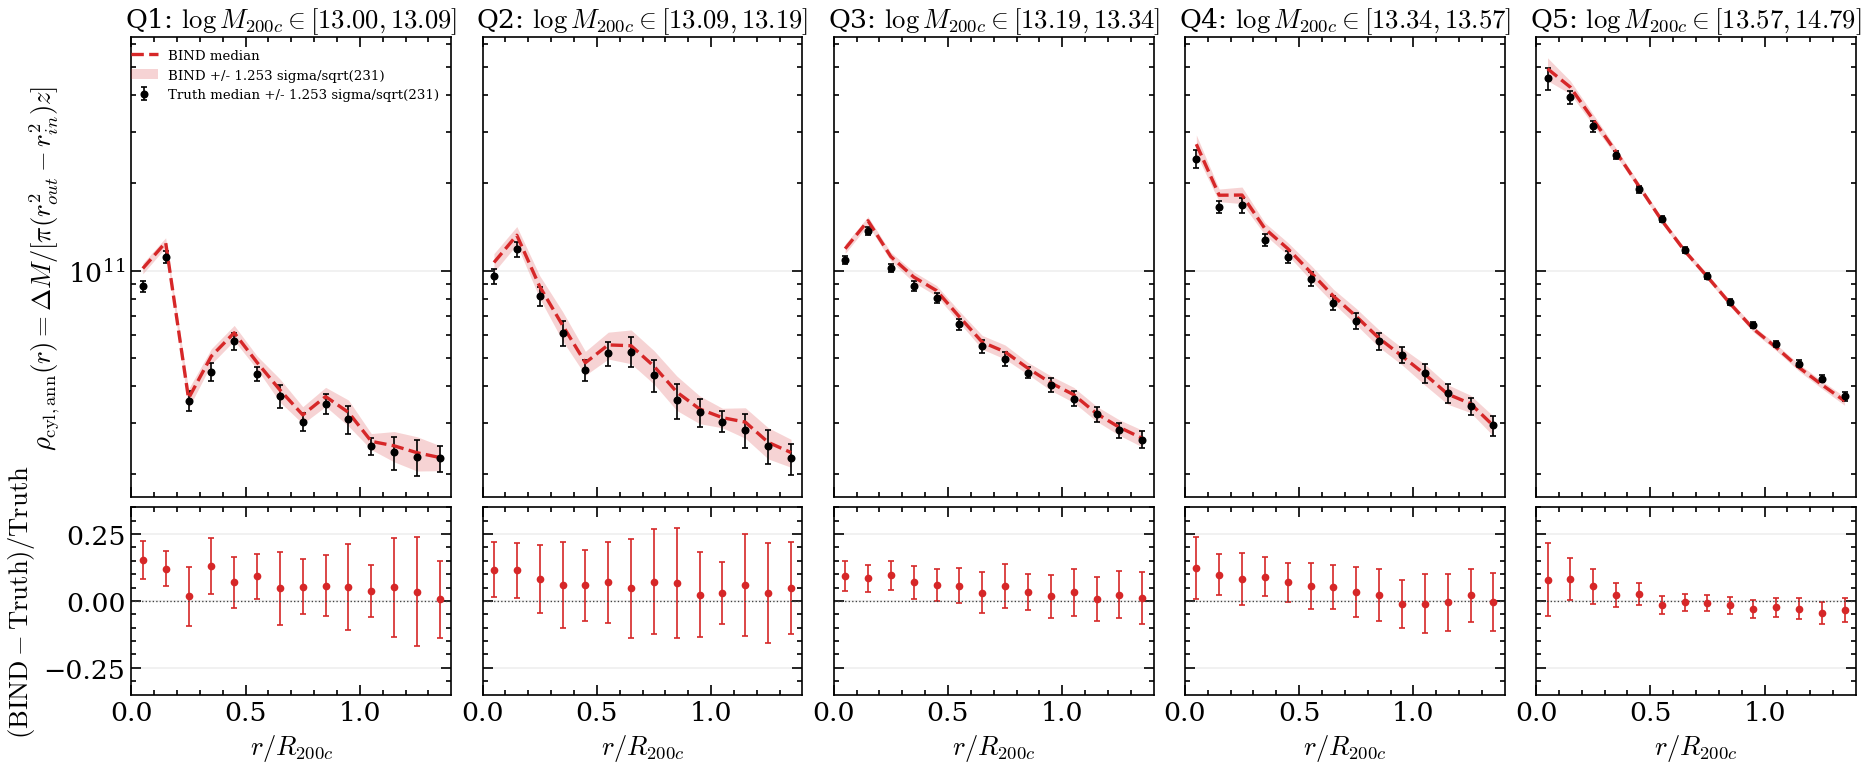

,quintile,mass_range,N_halos,shape_MAE_dex
0,1,"[13.000, 13.089]",231,0.0275
1,2,"[13.089, 13.192]",231,0.0263
2,3,"[13.192, 13.338]",230,0.0202
3,4,"[13.338, 13.574]",231,0.0204
4,5,"[13.574, 14.788]",231,0.0145


In [32]:
logm = cv_df['logM'].to_numpy(dtype=np.float64)
valid_m = np.isfinite(logm)
q_edges = np.quantile(logm[valid_m], np.linspace(0.0, 1.0, 6))
q_edges = np.unique(q_edges)
if len(q_edges) < 6:
    q_edges = np.linspace(np.nanmin(logm[valid_m]), np.nanmax(logm[valid_m]), 6)

nq = len(q_edges) - 1
r_edges = field_data['profile_edges']
r_cent = 0.5 * (r_edges[:-1] + r_edges[1:])

# Use fewer effective radial bins in the display.
PLOT_BIN_STRIDE = 2
n_use = (len(r_cent) // PLOT_BIN_STRIDE) * PLOT_BIN_STRIDE if PLOT_BIN_STRIDE > 1 else len(r_cent)
if n_use == 0:
    n_use = len(r_cent)

# User-requested projection depth for cylindrical density estimate.
Z_PROJ_MPC = 50.0

# Requested fixed-N approximation for median errors.
N_ERR_REF = 231.0
MEDIAN_GAUSS_FACTOR = 1.2533141373155001

if 'cv_r200_mpc' not in globals():
    print('cv_r200_mpc not found; using mass-derived R200 from logM for all CV halos.')
    m200 = 10.0 ** cv_df['logM'].to_numpy(dtype=np.float64)
    cv_r200_mpc = (3.0 * m200 / (4.0 * np.pi * 200.0 * RHO_CRIT)) ** (1.0 / 3.0)


def _coarsen_profile_rows(arr, stride, n_keep):
    arr = arr[:, :n_keep]
    if stride <= 1:
        return arr
    return np.nanmean(arr.reshape(arr.shape[0], n_keep // stride, stride), axis=2)


def _coarsen_radius_grid(r_scaled, stride, n_keep):
    r_scaled = r_scaled[:n_keep]
    if stride <= 1:
        return r_scaled
    return np.nanmean(r_scaled.reshape(-1, stride), axis=1)


def _annular_cyl_density_from_annfrac(ann_frac, m_tot, r200_mpc, edges_scaled, z_proj_mpc):
    ann_frac = np.asarray(ann_frac, dtype=np.float64)
    m_tot = np.asarray(m_tot, dtype=np.float64)
    r200_mpc = np.asarray(r200_mpc, dtype=np.float64)
    edges_scaled = np.asarray(edges_scaled, dtype=np.float64)

    n_h, n_b = ann_frac.shape
    if len(edges_scaled) != (n_b + 1):
        raise ValueError('edges_scaled length must be number_of_bins + 1')

    out = np.full((n_h, n_b), np.nan, dtype=np.float64)

    for ih in range(n_h):
        mt = m_tot[ih]
        r2 = r200_mpc[ih]
        if (not np.isfinite(mt)) or (mt <= 0) or (not np.isfinite(r2)) or (r2 <= 0):
            continue

        frac = ann_frac[ih]
        ok = np.isfinite(frac) & (frac >= 0)
        if not np.any(ok):
            continue

        dm = np.full(n_b, np.nan, dtype=np.float64)
        dm[ok] = frac[ok] * mt

        r_lo = edges_scaled[:-1] * r2
        r_hi = edges_scaled[1:] * r2
        ann_area = np.pi * np.maximum(r_hi ** 2 - r_lo ** 2, 1e-12)
        ann_vol = ann_area * z_proj_mpc

        out[ih, ok] = dm[ok] / ann_vol[ok]

    return out


def _median_se_gaussian(arr, n_ref=N_ERR_REF):
    arr = np.asarray(arr, dtype=np.float64)
    n_bins = arr.shape[1]
    se = np.full(n_bins, np.nan, dtype=np.float64)

    for j in range(n_bins):
        v = arr[:, j]
        v = v[np.isfinite(v)]
        if len(v) < 2:
            continue
        sigma = np.nanstd(v, ddof=1)
        se[j] = MEDIAN_GAUSS_FACTOR * sigma / np.sqrt(float(n_ref))

    return se


r_plot = _coarsen_radius_grid(r_cent, PLOT_BIN_STRIDE, n_use)

fig, axes = plt.subplots(
    2,
    nq,
    figsize=(3.1 * nq, 6.4),
    sharex='col',
    sharey='row',
    gridspec_kw={'height_ratios': [3.2, 1.3]},
    constrained_layout=True,
)

if nq == 1:
    axes = np.array([[axes[0]], [axes[1]]])

shape_rows = []

for i in range(nq):
    mlo = q_edges[i]
    mhi = q_edges[i + 1]
    if i < nq - 1:
        m = (logm >= mlo) & (logm < mhi)
    else:
        m = (logm >= mlo) & (logm <= mhi)

    pt = field_data['gas_prof_truth'][m, :n_use]
    pg = field_data['gas_prof_bind'][m, :n_use]

    m_t = cv_df.loc[m, 'truth_M_gas'].to_numpy(dtype=np.float64)
    m_g = cv_df.loc[m, 'gen_M_gas'].to_numpy(dtype=np.float64)
    r200_here = cv_r200_mpc[m]

    edges_use = r_edges[: n_use + 1]
    rho_t = _annular_cyl_density_from_annfrac(pt, m_t, r200_here, edges_use, Z_PROJ_MPC)
    rho_g = _annular_cyl_density_from_annfrac(pg, m_g, r200_here, edges_use, Z_PROJ_MPC)

    rho_t_plot = _coarsen_profile_rows(rho_t, PLOT_BIN_STRIDE, n_use)
    rho_g_plot = _coarsen_profile_rows(rho_g, PLOT_BIN_STRIDE, n_use)

    med_t = np.nanmedian(rho_t_plot, axis=0)
    med_g = np.nanmedian(rho_g_plot, axis=0)
    err_t = _median_se_gaussian(rho_t_plot, n_ref=N_ERR_REF)
    err_g = _median_se_gaussian(rho_g_plot, n_ref=N_ERR_REF)

    with np.errstate(divide='ignore', invalid='ignore'):
        med_res = np.full_like(med_t, np.nan, dtype=np.float64)
        err_res = np.full_like(med_t, np.nan, dtype=np.float64)
        ok_prop = np.isfinite(med_t) & np.isfinite(med_g) & np.isfinite(err_t) & np.isfinite(err_g) & (med_t > 0)
        med_res[ok_prop] = (med_g[ok_prop] - med_t[ok_prop]) / med_t[ok_prop]
        err_res[ok_prop] = np.sqrt(
            (err_g[ok_prop] / med_t[ok_prop]) ** 2
            + ((med_g[ok_prop] * err_t[ok_prop]) / (med_t[ok_prop] ** 2)) ** 2
        )

    ok_ratio = np.isfinite(med_t) & np.isfinite(med_g) & (med_t > 0) & (med_g > 0)
    ratio_medline = np.full_like(med_t, np.nan, dtype=np.float64)
    ratio_medline[ok_ratio] = np.log10(med_g[ok_ratio] / med_t[ok_ratio])

    shape_mae = float(np.nanmean(np.abs(ratio_medline[ok_ratio]))) if ok_ratio.any() else np.nan

    shape_rows.append({
        'quintile': i + 1,
        'mass_range': f'[{mlo:.3f}, {mhi:.3f}]',
        'N_halos': int(m.sum()),
        'shape_MAE_dex': shape_mae,
    })

    ax = axes[0, i]
    axr = axes[1, i]

    ok_t = np.isfinite(med_t) & np.isfinite(err_t) & (med_t > 0)
    ok_g = np.isfinite(med_g) & np.isfinite(err_g) & (med_g > 0)

    ax.errorbar(
        r_plot[ok_t],
        med_t[ok_t],
        yerr=err_t[ok_t],
        fmt='o',
        ms=3.8,
        color='k',
        ecolor='k',
        elinewidth=1.0,
        capsize=2.0,
        lw=0,
        label='Truth median +/- 1.253 sigma/sqrt(231)' if i == 0 else None,
    )

    ax.plot(r_plot[ok_g], med_g[ok_g], '--', color='tab:red', lw=2.0, label='BIND median' if i == 0 else None)
    low_g = np.maximum(med_g[ok_g] - err_g[ok_g], 1e-30)
    high_g = med_g[ok_g] + err_g[ok_g]
    ax.fill_between(
        r_plot[ok_g],
        low_g,
        high_g,
        color='tab:red',
        alpha=0.20,
        lw=0,
        label='BIND +/- 1.253 sigma/sqrt(231)' if i == 0 else None,
    )

    ax.set_title(rf'Q{i+1}: $\log M_{{200c}}\in[{mlo:.2f},{mhi:.2f}]$')
    ax.set_yscale('log')
    ax.set_xlim(0.0, r_edges[-1])
    ax.grid(axis='y', alpha=0.2)

    ok_res = np.isfinite(med_res) & np.isfinite(err_res)
    axr.errorbar(
        r_plot[ok_res],
        med_res[ok_res],
        yerr=err_res[ok_res],
        fmt='o',
        ms=3.6,
        color='tab:red',
        ecolor='tab:red',
        elinewidth=1.0,
        capsize=1.8,
        lw=0,
    )
    axr.axhline(0.0, color='0.25', lw=0.8, ls=':')
    axr.set_xlim(0.0, r_edges[-1])
    axr.set_ylim(-0.35, 0.35)
    axr.grid(axis='y', alpha=0.2)

for i in range(nq):
    axes[1, i].set_xlabel(r'$r/R_{200c}$')

axes[0, 0].set_ylabel(r'$\rho_{\rm cyl,ann}(r)=\Delta M/[\pi(r_{out}^2-r_{in}^2)z]$')
axes[1, 0].set_ylabel(r'$(\mathrm{BIND}-\mathrm{Truth})/\mathrm{Truth}$')
axes[0, 0].legend(loc='best', fontsize=8, frameon=False)

save_fig(fig, 'beyond_mass_testA_radial_shape_quintiles_residual')
plt.show()

shape_df = pd.DataFrame(shape_rows)
display(shape_df.round(4))

## Test B: Cross-Channel Spatial Covariance

We compare isotropic cross-correlation spectra $r_{\rm gas\times DM}(k)$ and $r_{\rm star\times DM}(k)$.
These are field-level diagnostics not implied by matching scalar masses.

  wrote paper_figures/beyond_mass_testB_cross_channel_covariance.pdf
  wrote paper_figures/beyond_mass_testB_cross_channel_covariance.png


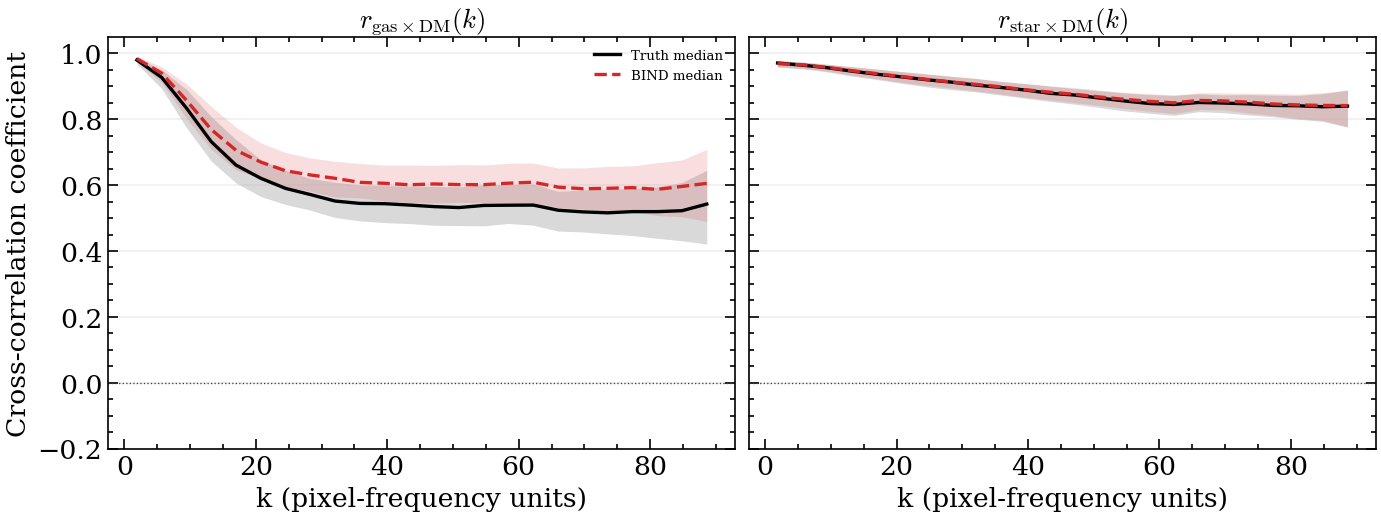

,pair,median_abs_delta_r,p90_abs_delta_r
0,gas_x_dm,0.0664,0.1799
1,star_x_dm,0.0204,0.0727


In [6]:
k = field_data['k_centers']
k_ok = np.isfinite(k) & (k > 1.0)

pairs = [
    ('cross_gd_truth', 'cross_gd_bind', r'$r_{\rm gas\times DM}(k)$', 'gas_x_dm'),
    ('cross_sd_truth', 'cross_sd_bind', r'$r_{\rm star\times DM}(k)$', 'star_x_dm'),
]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3), sharey=True, constrained_layout=True)
cov_rows = []

for ax, (tk, bk, ylabel, short) in zip(axes, pairs):
    rt = field_data[tk]
    rb = field_data[bk]

    med_t = np.nanmedian(rt, axis=0)
    med_b = np.nanmedian(rb, axis=0)
    q25_t, q75_t = np.nanpercentile(rt, [25, 75], axis=0)
    q25_b, q75_b = np.nanpercentile(rb, [25, 75], axis=0)

    ax.plot(k, med_t, '-', color='k', lw=2.0, label='Truth median')
    ax.fill_between(k, q25_t, q75_t, color='k', alpha=0.15, lw=0)
    ax.plot(k, med_b, '--', color='tab:red', lw=2.0, label='BIND median')
    ax.fill_between(k, q25_b, q75_b, color='tab:red', alpha=0.15, lw=0)

    ax.axhline(0.0, color='0.25', lw=0.8, ls=':')
    ax.set_xlabel('k (pixel-frequency units)')
    ax.set_title(ylabel)
    ax.grid(axis='y', alpha=0.2)
    ax.set_ylim(-0.2, 1.05)

    delta = np.abs(rt[:, k_ok] - rb[:, k_ok])
    cov_rows.append({
        'pair': short,
        'median_abs_delta_r': float(np.nanmedian(delta)),
        'p90_abs_delta_r': float(np.nanpercentile(delta, 90)),
    })

axes[0].set_ylabel('Cross-correlation coefficient')
axes[0].legend(loc='best', fontsize=8, frameon=False)

save_fig(fig, 'beyond_mass_testB_cross_channel_covariance')
plt.show()

cov_df = pd.DataFrame(cov_rows)
display(cov_df.round(4))

## Test C: Parameter Dependence Scaffolding (1P or SB35)

This section is intentionally scaffolded to build up from parameter coverage to response interpretation.

1. Choose a suite with parameter variation: **1P** (single-parameter sweeps) or **Test/SB35** (all parameters varied).
2. Build gas-shape metrics from maps (concentration and outer slope), plus gas-mass normalization.
3. Rank parameter dependencies with partial correlations controlling for mass.
4. Plot response curves for the strongest parameters so we can see whether shape changes are learned,
   not only total-mass normalization shifts.

Test C suite: Test
  sims:  102
  halos: 4272
Varying parameters detected: 35 / 35


,p_idx,label,n_finite,std,iqr,n_unique_6dp
0,15,p15,4272,1073.513806,1919.639954,101
1,17,p17,4272,114.149375,227.929993,101
2,6,$A_{\rm AGN2}$,4272,9.130683,16.700000,101
3,3,$A_{\rm SN1}$,4272,3.400992,3.971000,101
4,5,$A_{\rm SN2}$,4272,2.964873,3.939500,101
5,29,p29,4272,2.205868,3.492600,101
6,13,p13,4272,2.190883,3.350101,101
7,24,p24,4272,1.875502,2.120250,101
8,30,p30,4272,1.473748,2.741700,101
9,28,p28,4272,1.146066,1.851800,101


Loaded Test C cache: analysis_physics_cache/beyond_mass_param_shape_test_rmax140_v2.npz
Top parameters for plotting: [28, 6, 1, 7, 26, 4]


,p_idx,p_label,mean_abs_rho_truth,mean_abs_rho_bind
0,28,p28,0.2268,0.1532
1,6,$A_{\rm AGN2}$,0.2178,0.1899
2,1,$\Omega_m$,0.2106,0.2360
3,7,$\Omega_b$,0.1447,0.1706
4,26,p26,0.1426,0.1358
5,21,p21,0.1411,0.1375
6,3,$A_{\rm SN1}$,0.1396,0.1352
7,27,p27,0.1385,0.1658
8,32,p32,0.1364,0.1356
9,5,$A_{\rm SN2}$,0.1348,0.1403


  wrote paper_figures/beyond_mass_testC_param_heatmap_test.pdf
  wrote paper_figures/beyond_mass_testC_param_heatmap_test.png


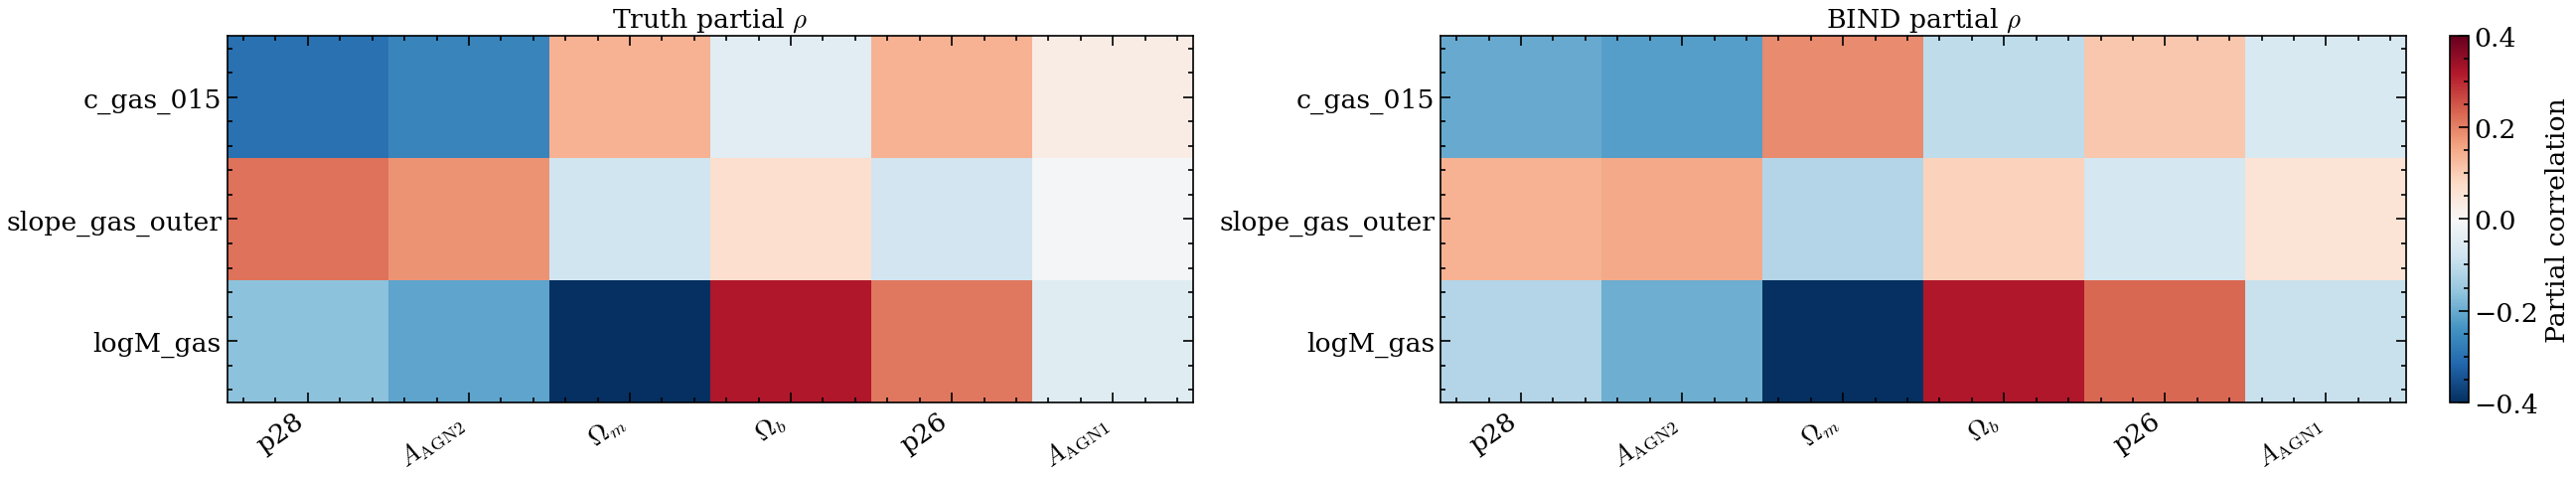

  wrote paper_figures/beyond_mass_testC_param_response_curves_test.pdf
  wrote paper_figures/beyond_mass_testC_param_response_curves_test.png


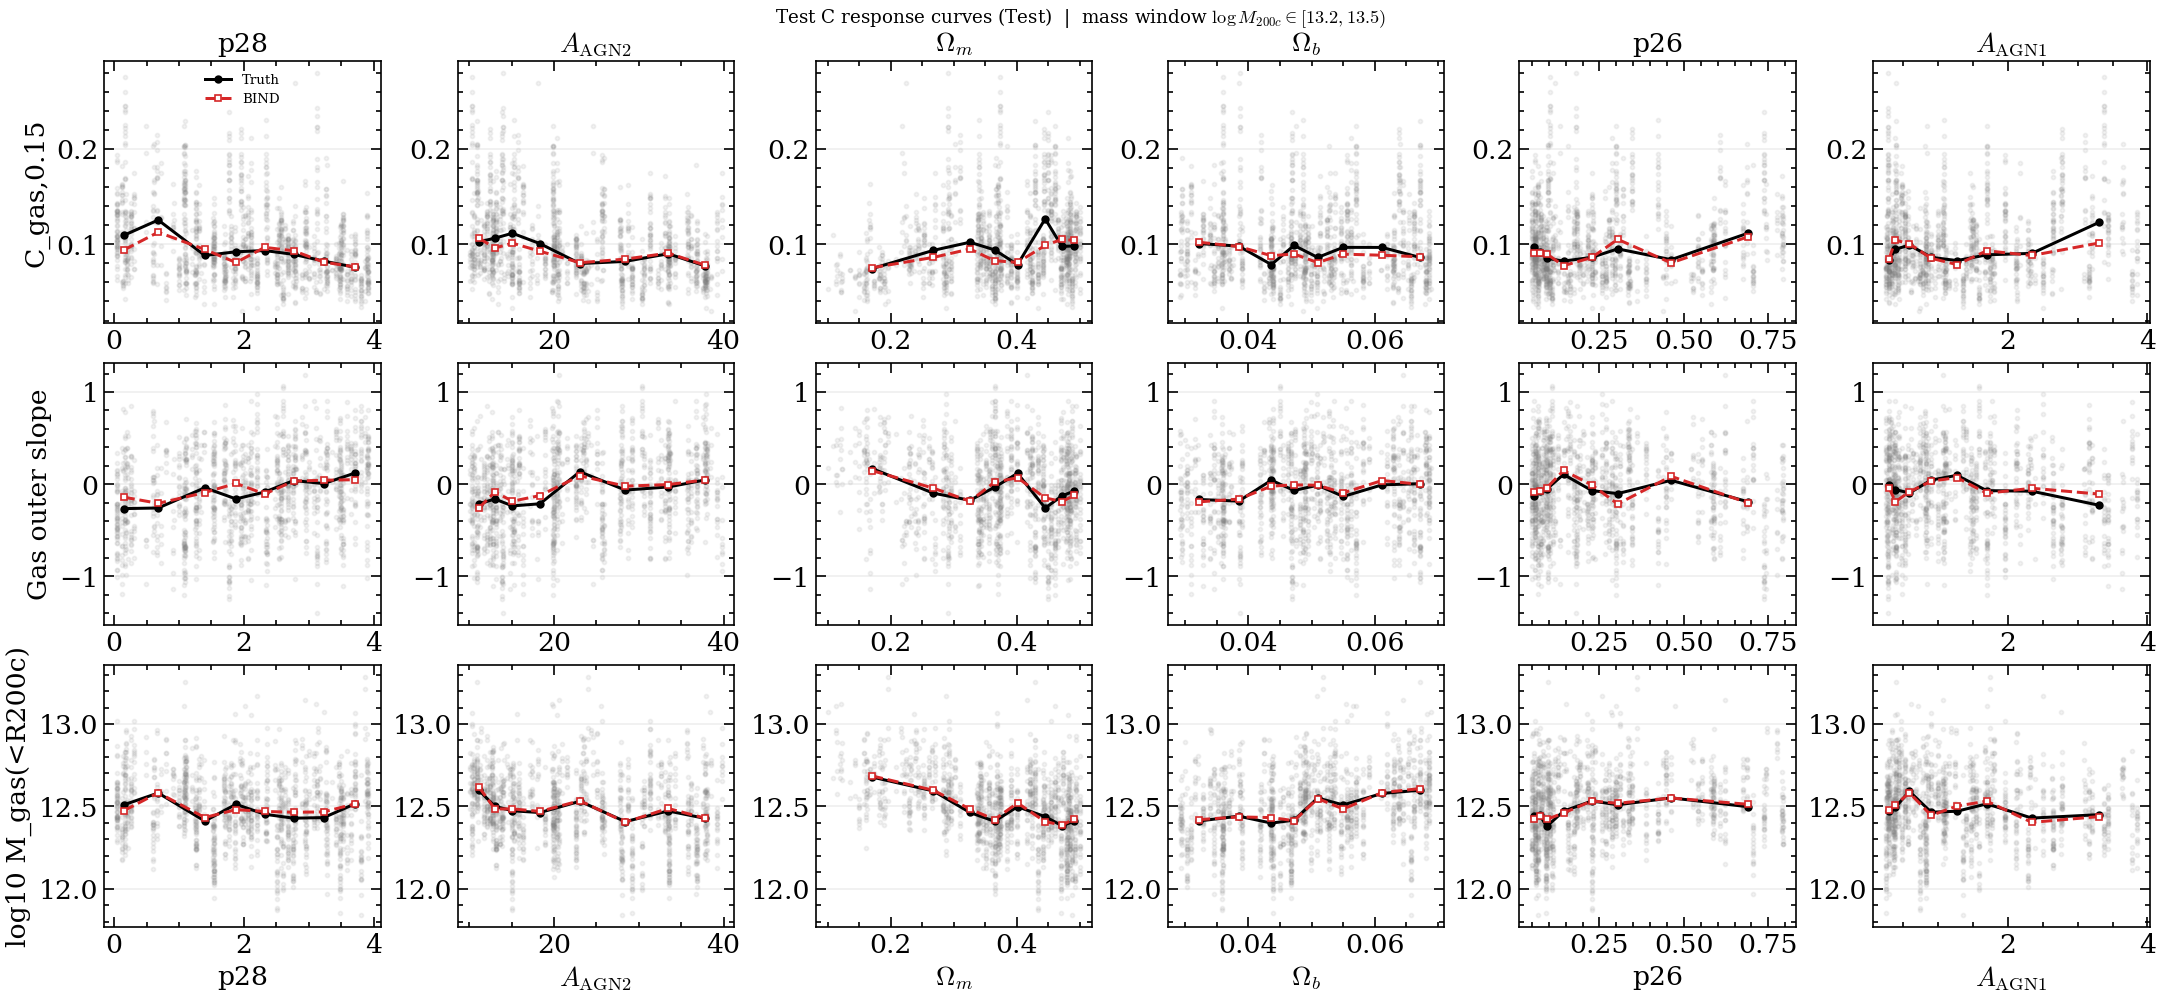

,p_idx,p_label,metric,rho_truth,p_truth,rho_bind,p_bind
0,6,$A_{\rm AGN2}$,c_gas_015,-0.2634,0.0000,-0.2214,0.0000
1,6,$A_{\rm AGN2}$,slope_gas_outer,0.1804,0.0000,0.1522,0.0000
2,6,$A_{\rm AGN2}$,logM_gas,-0.2097,0.0000,-0.1963,0.0000
3,28,p28,c_gas_015,-0.2984,0.0000,-0.2031,0.0000
4,28,p28,slope_gas_outer,0.2163,0.0000,0.1404,0.0000
5,28,p28,logM_gas,-0.1656,0.0000,-0.1162,0.0000
6,4,$A_{\rm AGN1}$,c_gas_015,0.0305,0.0465,-0.0609,0.0001
7,4,$A_{\rm AGN1}$,slope_gas_outer,-0.0087,0.5691,0.0541,0.0004
8,4,$A_{\rm AGN1}$,logM_gas,-0.0469,0.0022,-0.0892,0.0000
9,26,p26,c_gas_015,0.1394,0.0000,0.1091,0.0000


In [33]:
# ------------------------------
# Test C configuration
# ------------------------------
PARAM_SUITE = 'Test'   # set to '1P' or 'Test' (SB35)
TOP_N_PARAMS = 6
MASS_WINDOW = (13.2, 13.5)

if PARAM_SUITE not in ('1P', 'Test'):
    raise ValueError("PARAM_SUITE must be '1P' or 'Test'.")

resp_df = obs_df[obs_df['suite'] == PARAM_SUITE].copy().reset_index(drop=True)
resp_df['halo_in_sim'] = resp_df.groupby('sim_id').cumcount()
resp_sims = sims[sims['suite'] == PARAM_SUITE].copy().reset_index(drop=True)

print(f'Test C suite: {PARAM_SUITE}')
print(f'  sims:  {len(resp_sims)}')
print(f'  halos: {len(resp_df)}')

# ------------------------------
# Parameter spread audit
# ------------------------------
PARAM_LABELS = {
    1: r'$\Omega_m$', 2: r'$\sigma_8$', 3: r'$A_{\rm SN1}$', 4: r'$A_{\rm AGN1}$',
    5: r'$A_{\rm SN2}$', 6: r'$A_{\rm AGN2}$', 7: r'$\Omega_b$', 8: r'$h$', 9: r'$n_s$'
}


def p_label(j):
    return PARAM_LABELS.get(j, f'p{j}')


spread_rows = []
for j in range(1, N_PARAMS + 1):
    v = resp_df[f'p{j}'].to_numpy(dtype=np.float64)
    ok = np.isfinite(v)
    if ok.sum() == 0:
        spread_rows.append({'p_idx': j, 'label': p_label(j), 'n_finite': 0, 'std': np.nan, 'iqr': np.nan, 'n_unique_6dp': 0})
        continue
    vv = v[ok]
    spread_rows.append({
        'p_idx': j,
        'label': p_label(j),
        'n_finite': int(ok.sum()),
        'std': float(np.nanstd(vv)),
        'iqr': float(np.nanpercentile(vv, 75) - np.nanpercentile(vv, 25)),
        'n_unique_6dp': int(len(np.unique(np.round(vv, 6)))),
    })

spread_df = pd.DataFrame(spread_rows).sort_values('std', ascending=False).reset_index(drop=True)
varying_params = spread_df[np.isfinite(spread_df['std']) & (spread_df['std'] > 1e-10)]['p_idx'].astype(int).tolist()

print(f'Varying parameters detected: {len(varying_params)} / {N_PARAMS}')
display(spread_df.head(15).round(6))

# ------------------------------
# Build shape cache for selected suite
# ------------------------------
RESP_CACHE = CACHE_DIR / f'beyond_mass_param_shape_{PARAM_SUITE.lower()}_rmax140_v2.npz'


def build_param_shape_cache(resp_df, resp_sims, force=False):
    if RESP_CACHE.exists() and not force:
        z = np.load(RESP_CACHE, allow_pickle=True)
        print(f'Loaded Test C cache: {RESP_CACHE}')
        return {k: z[k] for k in z.files}

    N = len(resp_df)
    c_gas_truth = np.full(N, np.nan, dtype=np.float64)
    c_gas_bind = np.full(N, np.nan, dtype=np.float64)
    slope_gas_truth = np.full(N, np.nan, dtype=np.float64)
    slope_gas_bind = np.full(N, np.nan, dtype=np.float64)

    by_sim = {sid: np.where(resp_df['sim_id'].to_numpy() == sid)[0] for sid in resp_df['sim_id'].unique()}

    for ii, rec in enumerate(resp_sims.to_dict('records')):
        sid = rec['sim_id']
        rows = by_sim.get(sid, np.array([], dtype=int))
        if len(rows) == 0:
            continue

        cat = np.load(rec['halo_catalog'])
        fm = np.load(rec['full_maps'])
        gen = np.load(rec['generated'])['generated']

        centers_pix = _centers_to_pixels(cat['centers'])
        masses = cat['masses'].astype(np.float64)
        if 'radii' in cat.files:
            radii_pix = cat['radii'].astype(np.float64) / 1000.0 / MPC_PER_PIX
        else:
            radii_pix = np.array([r200c_pix(float(m)) for m in masses], dtype=np.float64)

        halo_idx = resp_df.loc[rows, 'halo_in_sim'].to_numpy(dtype=int)

        for row, hi in zip(rows, halo_idx):
            if hi < 0 or hi >= len(masses):
                continue

            cx, cy = centers_pix[hi]
            gas_t = _extract_patch(fm['truth_maps'][1], cx, cy)
            gas_g = gen[hi, 1]

            r200p = float(radii_pix[hi])
            r_aper = max(min(r200p, PATCH_PIX / 2 - 2), 4.0)
            r_inner = max(0.15 * r_aper, 2.0)

            prof_t = mass_fraction_profile(gas_t, r_aper, PROFILE_EDGES)
            prof_g = mass_fraction_profile(gas_g, r_aper, PROFILE_EDGES)
            slope_gas_truth[row] = profile_slope(prof_t, PROFILE_EDGES)
            slope_gas_bind[row] = profile_slope(prof_g, PROFILE_EDGES)

            m_t = aperture_sum(gas_t, r_aper)
            m_g = aperture_sum(gas_g, r_aper)
            if m_t > 0:
                c_gas_truth[row] = aperture_sum(gas_t, r_inner) / m_t
            if m_g > 0:
                c_gas_bind[row] = aperture_sum(gas_g, r_inner) / m_g

        if (ii + 1) % 10 == 0:
            print(f'  processed {ii + 1}/{len(resp_sims)} {PARAM_SUITE} sims')

    out = {
        'c_gas_truth': c_gas_truth,
        'c_gas_bind': c_gas_bind,
        'slope_gas_truth': slope_gas_truth,
        'slope_gas_bind': slope_gas_bind,
    }
    np.savez_compressed(RESP_CACHE, **out)
    print(f'Wrote Test C cache: {RESP_CACHE}')
    return out


shape_cache = build_param_shape_cache(resp_df, resp_sims, force=False)

# ------------------------------
# Metrics and partial dependencies
# ------------------------------
logM_resp = resp_df['logM'].to_numpy(dtype=np.float64)
with np.errstate(divide='ignore', invalid='ignore'):
    logM_gas_truth = np.where(resp_df['truth_M_gas'].to_numpy(dtype=np.float64) > 0, np.log10(resp_df['truth_M_gas'].to_numpy(dtype=np.float64)), np.nan)
    logM_gas_bind = np.where(resp_df['gen_M_gas'].to_numpy(dtype=np.float64) > 0, np.log10(resp_df['gen_M_gas'].to_numpy(dtype=np.float64)), np.nan)

metric_defs = [
    ('c_gas_015', shape_cache['c_gas_truth'], shape_cache['c_gas_bind']),
    ('slope_gas_outer', shape_cache['slope_gas_truth'], shape_cache['slope_gas_bind']),
    ('logM_gas', logM_gas_truth, logM_gas_bind),
]

rows = []
for p in varying_params:
    x = resp_df[f'p{p}'].to_numpy(dtype=np.float64)
    for mname, y_t, y_b in metric_defs:
        rho_t, p_t = partial_spearman(x, y_t, logM_resp)
        rho_b, p_b = partial_spearman(x, y_b, logM_resp)
        rows.append({
            'p_idx': p,
            'p_label': p_label(p),
            'metric': mname,
            'rho_truth': rho_t,
            'p_truth': p_t,
            'rho_bind': rho_b,
            'p_bind': p_b,
        })

dep_df = pd.DataFrame(rows)

rank_df = (dep_df
           .groupby(['p_idx', 'p_label'], as_index=False)
           .agg(mean_abs_rho_truth=('rho_truth', lambda v: float(np.nanmean(np.abs(v)))),
                mean_abs_rho_bind=('rho_bind', lambda v: float(np.nanmean(np.abs(v))))))
rank_df = rank_df.sort_values('mean_abs_rho_truth', ascending=False).reset_index(drop=True)

top_params = rank_df['p_idx'].head(TOP_N_PARAMS).tolist()
if (4 in varying_params) and (4 not in top_params):
    top_params = top_params[:-1] + [4]

print(f'Top parameters for plotting: {top_params}')
display(rank_df.head(12).round(4))

# Heatmaps: Truth vs BIND partial dependencies for top parameters
metric_order = ['c_gas_015', 'slope_gas_outer', 'logM_gas']

pt = (dep_df[dep_df['p_idx'].isin(top_params)]
      .pivot(index='metric', columns='p_idx', values='rho_truth')
      .reindex(index=metric_order, columns=top_params))
pb = (dep_df[dep_df['p_idx'].isin(top_params)]
      .pivot(index='metric', columns='p_idx', values='rho_bind')
      .reindex(index=metric_order, columns=top_params))

fig_hm, axs_hm = plt.subplots(1, 2, figsize=(3.2 * len(top_params) + 2.4, 4.0), constrained_layout=True)
for ax, mat, title in zip(axs_hm, [pt.values, pb.values], ['Truth partial $\\rho$', 'BIND partial $\\rho$']):
    im = ax.imshow(mat, cmap='RdBu_r', vmin=-0.4, vmax=0.4, aspect='auto')
    ax.set_xticks(np.arange(len(top_params)))
    ax.set_xticklabels([p_label(p) for p in top_params], rotation=35, ha='right')
    ax.set_yticks(np.arange(len(metric_order)))
    ax.set_yticklabels(metric_order)
    ax.set_title(title)
cb = fig_hm.colorbar(im, ax=axs_hm.ravel().tolist(), fraction=0.04, pad=0.02)
cb.set_label('Partial correlation')
save_fig(fig_hm, f'beyond_mass_testC_param_heatmap_{PARAM_SUITE.lower()}')
plt.show()

# ------------------------------
# Response curves for top parameters
# ------------------------------
mlo, mhi = MASS_WINDOW
mass_sel = (logM_resp >= mlo) & (logM_resp < mhi)


def _binned_median(x, y, n_bins=8, min_count=15):
    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() < min_count:
        return np.array([]), np.array([])
    x_ok = x[ok]
    y_ok = y[ok]
    edges = np.unique(np.quantile(x_ok, np.linspace(0.0, 1.0, n_bins + 1)))
    if len(edges) < 5:
        return np.array([]), np.array([])
    bs_m = binned_statistic(x_ok, y_ok, statistic='median', bins=edges)
    bs_n = binned_statistic(x_ok, y_ok, statistic='count', bins=edges)
    xc = 0.5 * (edges[:-1] + edges[1:])
    keep = np.isfinite(bs_m.statistic) & (bs_n.statistic >= min_count)
    return xc[keep], bs_m.statistic[keep]


metric_plot_map = {
    'c_gas_015': (shape_cache['c_gas_truth'], shape_cache['c_gas_bind'], 'C_gas,0.15'),
    'slope_gas_outer': (shape_cache['slope_gas_truth'], shape_cache['slope_gas_bind'], 'Gas outer slope'),
    'logM_gas': (logM_gas_truth, logM_gas_bind, 'log10 M_gas(<R200c)'),
}

ncol = len(top_params)
nrow = len(metric_order)
fig, axes = plt.subplots(nrow, ncol, figsize=(3.0 * ncol, 2.7 * nrow), squeeze=False, constrained_layout=True)

for ci, p in enumerate(top_params):
    x = resp_df[f'p{p}'].to_numpy(dtype=np.float64)
    for ri, mname in enumerate(metric_order):
        y_t, y_b, ylabel = metric_plot_map[mname]
        ax = axes[ri, ci]

        st = mass_sel & np.isfinite(x) & np.isfinite(y_t)
        sb = mass_sel & np.isfinite(x) & np.isfinite(y_b)

        ax.scatter(x[st], y_t[st], s=6, alpha=0.10, color='0.5', rasterized=True)

        xt, mt = _binned_median(x[st], y_t[st], n_bins=8, min_count=12)
        xb, mb = _binned_median(x[sb], y_b[sb], n_bins=8, min_count=12)
        if len(xt):
            ax.plot(xt, mt, 'o-', color='k', lw=1.8, ms=4, label='Truth' if (ri == 0 and ci == 0) else None)
        if len(xb):
            ax.plot(xb, mb, 's--', color='tab:red', lw=1.8, ms=4, mfc='white', label='BIND' if (ri == 0 and ci == 0) else None)

        if ri == 0:
            ax.set_title(p_label(p))
        if ci == 0:
            ax.set_ylabel(ylabel)
        if ri == nrow - 1:
            ax.set_xlabel(p_label(p))
        ax.grid(axis='y', alpha=0.2)

axes[0, 0].legend(loc='best', fontsize=8, frameon=False)
fig.suptitle(
    rf'Test C response curves ({PARAM_SUITE})  |  mass window $\log M_{{200c}}\in[{mlo:.1f},{mhi:.1f})$',
    y=1.02,
    fontsize=11,
)
save_fig(fig, f'beyond_mass_testC_param_response_curves_{PARAM_SUITE.lower()}')
plt.show()

dep_top_df = dep_df[dep_df['p_idx'].isin(top_params)].copy().reset_index(drop=True)
display(dep_top_df.round(4))

## Test D: SHMR Scatter Conditioned on Morphology

We test whether stellar-mass residuals at fixed mass carry morphology dependence.
If BIND reproduces this dependence, that is evidence for learned structure beyond mass assignment.

  wrote paper_figures/beyond_mass_testD_shmr_morphology.pdf
  wrote paper_figures/beyond_mass_testD_shmr_morphology.png


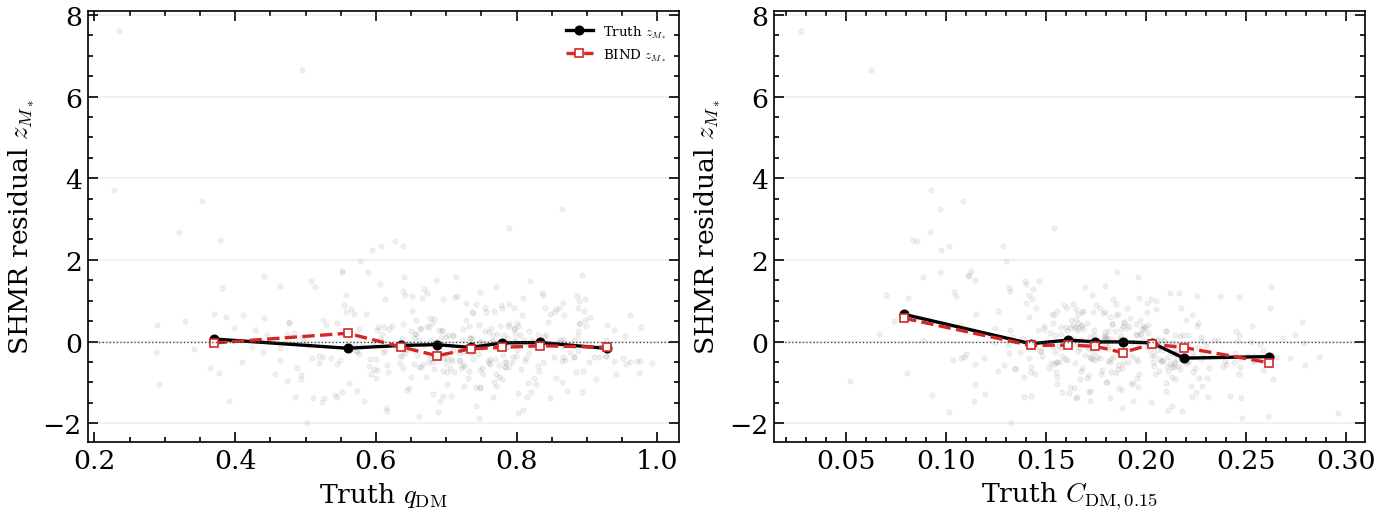

,morphology,rho_truth_partial(morph|M),p_truth,rho_bind_partial(morph|M),p_bind
0,q_dm,-0.0148,0.6149,-0.0884,0.0026
1,c_dm_015,-0.2568,0.0000,-0.2459,0.0000


In [15]:
logM = cv_df['logM'].to_numpy(dtype=np.float64)
logMstar_truth = np.where(cv_df['truth_M_star'].to_numpy() > 0, np.log10(cv_df['truth_M_star'].to_numpy()), np.nan)
logMstar_bind = np.where(cv_df['gen_M_star'].to_numpy() > 0, np.log10(cv_df['gen_M_star'].to_numpy()), np.nan)

fit_star_t = gp_zscore(logM, logMstar_truth, n_restarts=4)
fit_star_b = gp_zscore(logM, logMstar_bind, n_restarts=4)

z_star_t = fit_star_t['z_full']
z_star_b = fit_star_b['z_full']

q_dm = cv_df['truth_q_DM'].to_numpy(dtype=np.float64)
c_dm = field_data['c_dm_truth']

corr_rows = []
for morph_name, morph in [('q_dm', q_dm), ('c_dm_015', c_dm)]:
    rho_t, p_t = partial_spearman(morph, z_star_t, logM)
    rho_b, p_b = partial_spearman(morph, z_star_b, logM)
    corr_rows.append({
        'morphology': morph_name,
        'rho_truth_partial(morph|M)': rho_t,
        'p_truth': p_t,
        'rho_bind_partial(morph|M)': rho_b,
        'p_bind': p_b,
    })

mass_mid = (logM >= 13.2) & (logM < 13.5)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3), constrained_layout=True)
for ax, morph, xlabel in [
    (axes[0], q_dm, r'Truth $q_{\rm DM}$'),
    (axes[1], c_dm, r'Truth $C_{\rm DM,0.15}$'),
]:
    ok = mass_mid & np.isfinite(morph) & np.isfinite(z_star_t) & np.isfinite(z_star_b)
    ax.scatter(morph[ok], z_star_t[ok], s=8, alpha=0.10, color='0.5', rasterized=True)

    xt, mt = _binned_median(morph[ok], z_star_t[ok], n_bins=8, min_count=10)
    xb, mb = _binned_median(morph[ok], z_star_b[ok], n_bins=8, min_count=10)
    if len(xt):
        ax.plot(xt, mt, 'o-', color='k', lw=2.0, ms=5, label='Truth $z_{M_*}$')
    if len(xb):
        ax.plot(xb, mb, 's--', color='tab:red', lw=2.0, ms=5, mfc='white', label='BIND $z_{M_*}$')

    ax.axhline(0.0, color='0.25', lw=0.8, ls=':')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'SHMR residual $z_{M_*}$')
    ax.grid(axis='y', alpha=0.2)

axes[0].legend(loc='best', fontsize=8, frameon=False)
save_fig(fig, 'beyond_mass_testD_shmr_morphology')
plt.show()

corr_df = pd.DataFrame(corr_rows)
display(corr_df.round(4))

## Requested Headline Diagnostics (Baryon Residuals and Outlier Identity)

These are the three explicit tests:

1. Per-halo residual correlation $\rho(z_{\rm truth}, z_{\rm BIND})$.
2. Outlier identity preservation at $|z|\ge 3$ (precision/recall/F1/Jaccard).
3. Joint cross-observable signature for **BIND baryon outliers**.

  wrote paper_figures/beyond_mass_headline_tests12_signed.pdf
  wrote paper_figures/beyond_mass_headline_tests12_signed.png


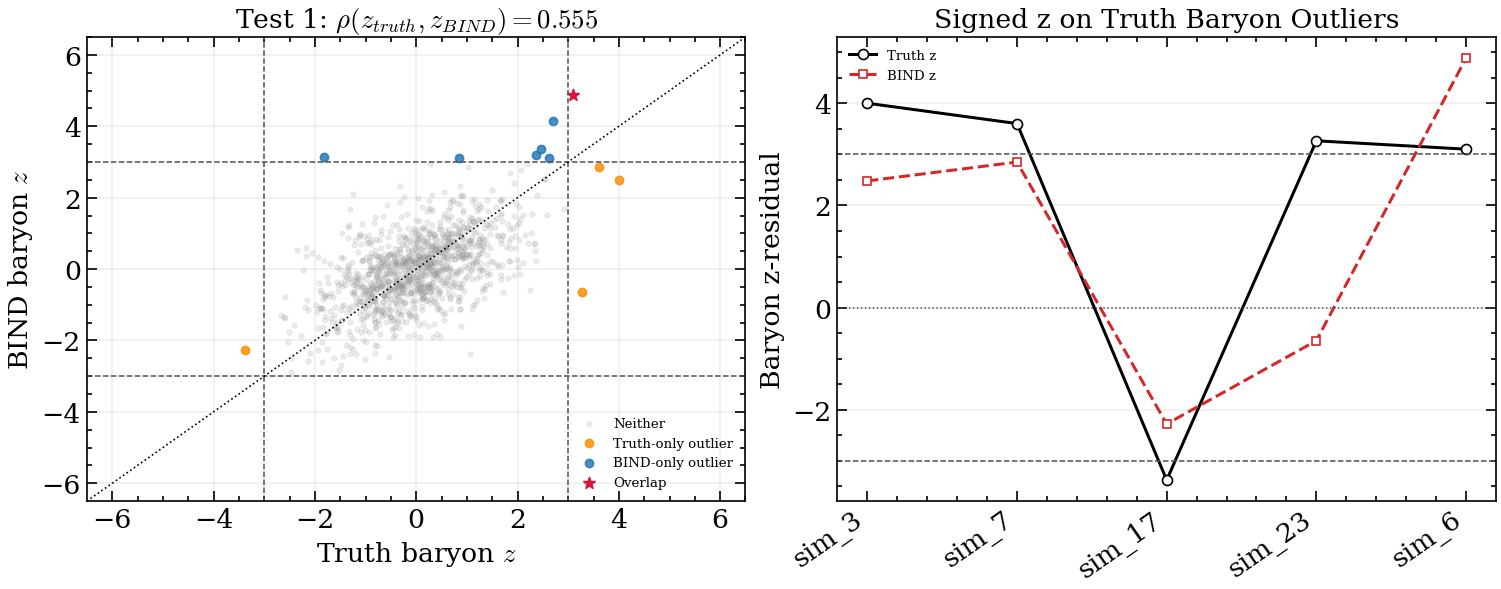

  wrote paper_figures/beyond_mass_headline_test3_joint_signature.pdf
  wrote paper_figures/beyond_mass_headline_test3_joint_signature.png


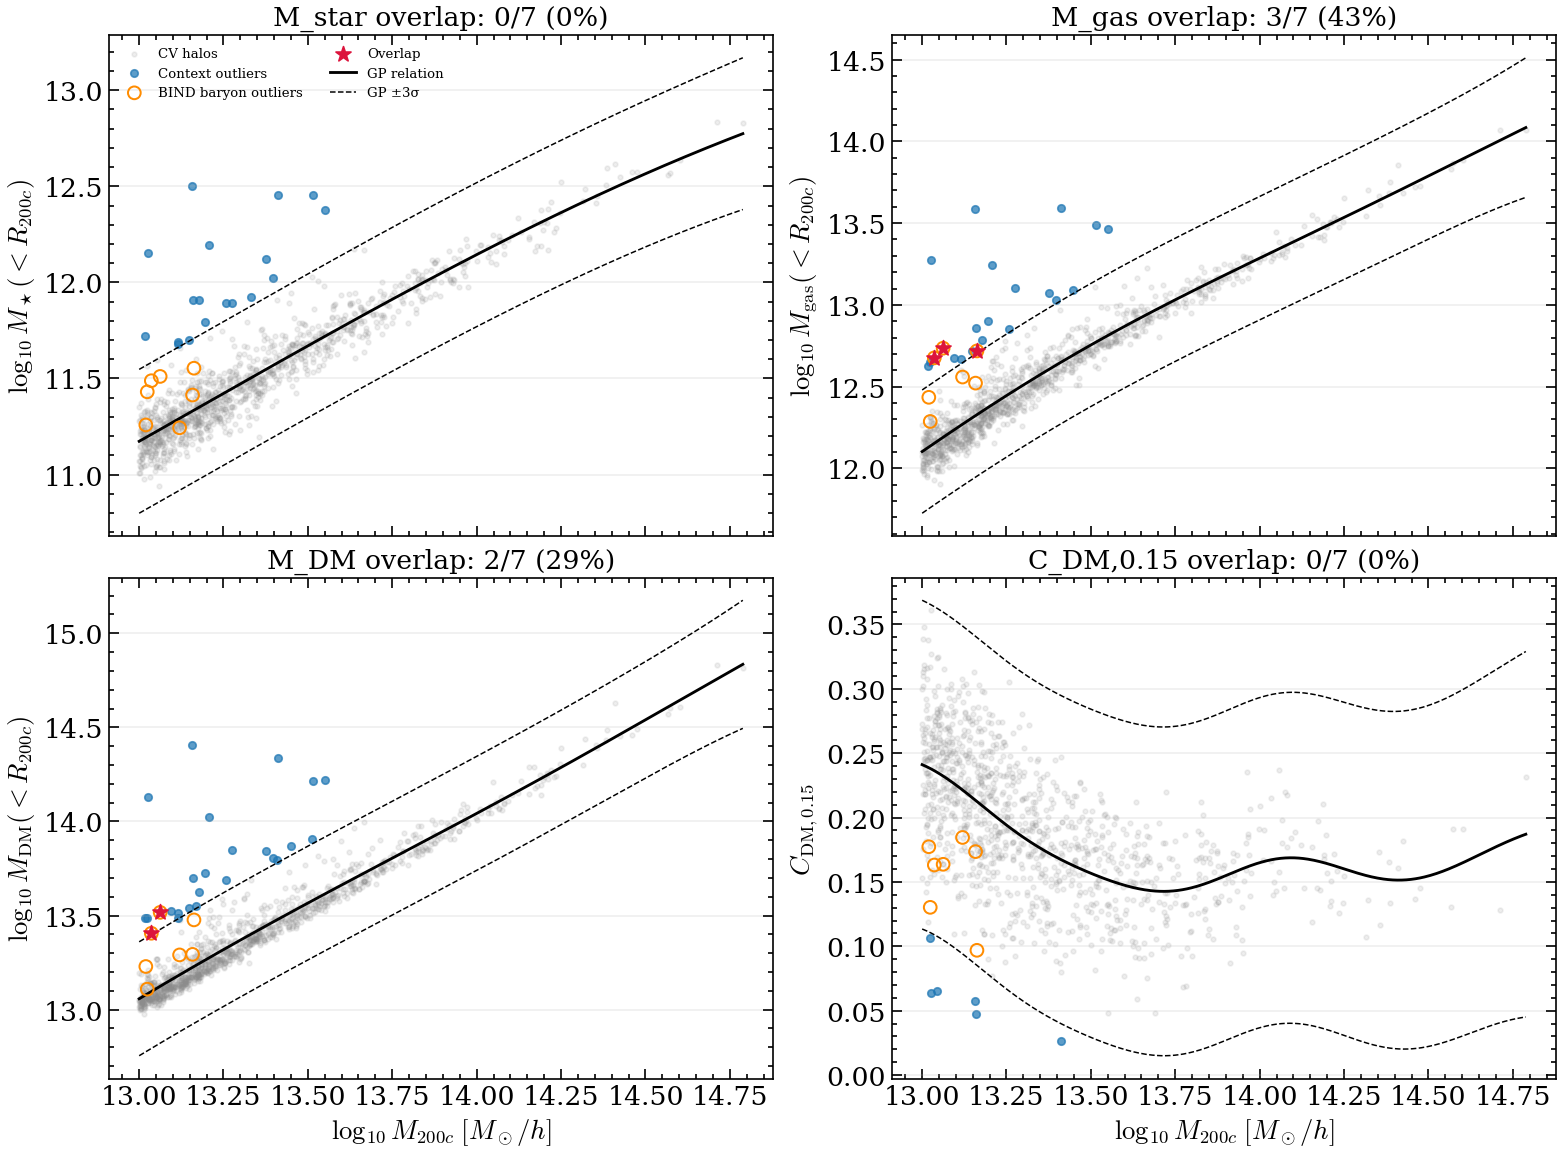

,N_matched_halos,rho_pearson_ztruth_zbind,p_value
0,1154,0.5546,0.0


,TP,FP,FN,TN,precision,recall,f1,jaccard,N_truth_outliers,N_bind_outliers
0,1,6,4,1143,0.1429,0.2,0.1667,0.0909,5,7


,context,N_bind_bary_with_data,N_context_outliers_on_bind_bary,N_above_on_bind_bary,N_below_on_bind_bary,median_z_on_bind_bary
0,M_star,7,0,0,0,1.7542
1,M_gas,7,3,3,0,2.4214
2,M_DM,7,2,2,0,1.4904
3,"C_DM,0.15",7,0,0,0,-1.6146


,halo_row,sim_id,logM,truth_f_b_norm,gen_f_b_norm,z_truth_bary,z_bind_bary,delta_z_bind_minus_truth,bind_also_outlier
0,884,sim_3,13.0309,0.9382,0.8563,4.0028,2.4810,-1.5218,False
1,1032,sim_7,13.2769,1.0102,0.9773,3.6043,2.8500,-0.7543,False
2,432,sim_17,13.1315,0.4652,0.5858,-3.3781,-2.2802,1.0979,False
3,734,sim_23,13.2683,0.9831,0.7484,3.2668,-0.6483,-3.9151,False
4,1011,sim_6,13.0365,0.8778,1.0131,3.1029,4.8869,1.7839,True


In [16]:
logM = cv_df['logM'].to_numpy(dtype=np.float64)

# Baryon GP residuals for truth and BIND
fit_bary_t = gp_zscore(logM, cv_df['truth_f_b_norm'].to_numpy(dtype=np.float64), n_restarts=6)
fit_bary_b = gp_zscore(logM, cv_df['gen_f_b_norm'].to_numpy(dtype=np.float64), n_restarts=6)

z_t = fit_bary_t['z_full']
z_b = fit_bary_b['z_full']
out_t = fit_bary_t['out_full']
out_b = fit_bary_b['out_full']

ok = np.isfinite(z_t) & np.isfinite(z_b)

# Test 1: per-halo residual rho
rho, p_rho = pearsonr(z_t[ok], z_b[ok])

# Test 2: outlier identity preservation
TP = int(np.sum(out_t[ok] & out_b[ok]))
FP = int(np.sum((~out_t[ok]) & out_b[ok]))
FN = int(np.sum(out_t[ok] & (~out_b[ok])))
TN = int(np.sum((~out_t[ok]) & (~out_b[ok])))

precision = TP / (TP + FP) if (TP + FP) > 0 else np.nan
recall = TP / (TP + FN) if (TP + FN) > 0 else np.nan
f1 = (2 * precision * recall / (precision + recall)
      if np.isfinite(precision) and np.isfinite(recall) and (precision + recall) > 0
      else np.nan)
jaccard = TP / (TP + FP + FN) if (TP + FP + FN) > 0 else np.nan

# Signed-residual diagnostics figure (requested follow-up)
both = ok & out_t & out_b
truth_only = ok & out_t & (~out_b)
bind_only = ok & (~out_t) & out_b
neither = ok & (~out_t) & (~out_b)

truth_idx = np.where(ok & out_t)[0]
truth_idx = truth_idx[np.argsort(np.abs(z_t[truth_idx]))[::-1]]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.9), constrained_layout=True)

ax = axes[0]
ax.scatter(z_t[neither], z_b[neither], s=8, alpha=0.14, color='0.55', rasterized=True, label='Neither')
ax.scatter(z_t[truth_only], z_b[truth_only], s=24, alpha=0.82, color='darkorange', label='Truth-only outlier')
ax.scatter(z_t[bind_only], z_b[bind_only], s=24, alpha=0.82, color='tab:blue', label='BIND-only outlier')
ax.scatter(z_t[both], z_b[both], s=52, marker='*', color='crimson', label='Overlap')
for v in (-3.0, 3.0):
    ax.axvline(v, color='0.3', ls='--', lw=0.9)
    ax.axhline(v, color='0.3', ls='--', lw=0.9)
lims = [-6.5, 6.5]
ax.plot(lims, lims, 'k:', lw=1.0)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(r'Truth baryon $z$')
ax.set_ylabel(r'BIND baryon $z$')
ax.set_title(rf'Test 1: $\rho(z_{{truth}}, z_{{BIND}}) = {rho:.3f}$')
ax.grid(alpha=0.2)
ax.legend(loc='lower right', fontsize=8, frameon=False)

ax2 = axes[1]
if len(truth_idx):
    rank = np.arange(len(truth_idx))
    labels = cv_df.loc[truth_idx, 'sim_id'].astype(str).to_numpy()
    ax2.plot(rank, z_t[truth_idx], 'o-', color='k', lw=1.8, ms=6, mfc='white', label='Truth z')
    ax2.plot(rank, z_b[truth_idx], 's--', color='tab:red', lw=1.8, ms=5, mfc='white', label='BIND z')
    ax2.set_xticks(rank)
    ax2.set_xticklabels(labels, rotation=35, ha='right')
for v in (-3.0, 0.0, 3.0):
    ax2.axhline(v, color='0.3', ls='--' if abs(v) == 3 else ':', lw=0.9)
ax2.set_ylabel('Baryon z-residual')
ax2.set_title('Signed z on Truth Baryon Outliers')
ax2.grid(axis='y', alpha=0.2)
ax2.legend(loc='best', fontsize=8, frameon=False)

save_fig(fig, 'beyond_mass_headline_tests12_signed')
plt.show()

# Test 3: joint signature for BIND baryon outliers
bind_bary = out_b.copy()

ctx_defs = [
    {
        'name': 'M_star',
        'y': np.where(cv_df['gen_M_star'].to_numpy() > 0, np.log10(cv_df['gen_M_star'].to_numpy()), np.nan),
        'ylabel': r'$\log_{10} M_\star(<R_{200c})$',
    },
    {
        'name': 'M_gas',
        'y': np.where(cv_df['gen_M_gas'].to_numpy() > 0, np.log10(cv_df['gen_M_gas'].to_numpy()), np.nan),
        'ylabel': r'$\log_{10} M_{\rm gas}(<R_{200c})$',
    },
    {
        'name': 'M_DM',
        'y': np.where(cv_df['gen_M_dm'].to_numpy() > 0, np.log10(cv_df['gen_M_dm'].to_numpy()), np.nan),
        'ylabel': r'$\log_{10} M_{\rm DM}(<R_{200c})$',
    },
    {
        'name': 'C_DM,0.15',
        'y': field_data['c_dm_bind'],
        'ylabel': r'$C_{\rm DM,0.15}$',
    },
]

fig2, axes2 = plt.subplots(2, 2, figsize=(13.0, 9.6), sharex=True, constrained_layout=True)
sig_rows = []

for pi, (ax, ctx) in enumerate(zip(axes2.flat, ctx_defs)):
    fit_ctx = gp_zscore(logM, ctx['y'], n_restarts=4)
    zc = fit_ctx['z_full']
    outc = fit_ctx['out_full']
    xg, mug, sigg = gp_curve_from_fit(fit_ctx, logM)

    valid = np.isfinite(logM) & np.isfinite(ctx['y'])
    overlap = valid & bind_bary & outc

    ax.scatter(logM[valid & (~bind_bary) & (~outc)], ctx['y'][valid & (~bind_bary) & (~outc)],
               s=8, alpha=0.14, color='0.55', rasterized=True, label='CV halos' if pi == 0 else None)
    ax.scatter(logM[valid & outc & (~bind_bary)], ctx['y'][valid & outc & (~bind_bary)],
               s=20, alpha=0.72, color='tab:blue', label='Context outliers' if pi == 0 else None)
    ax.scatter(logM[valid & bind_bary], ctx['y'][valid & bind_bary],
               s=58, facecolors='none', edgecolors='darkorange', linewidths=1.2,
               zorder=5, label='BIND baryon outliers' if pi == 0 else None)
    ax.scatter(logM[overlap], ctx['y'][overlap], s=90, marker='*', color='crimson',
               zorder=6, label='Overlap' if pi == 0 else None)

    ax.plot(xg, mug, 'k-', lw=1.7, label='GP relation' if pi == 0 else None)
    ax.plot(xg, mug + 3.0 * sigg, 'k--', lw=0.9, label='GP ±3σ' if pi == 0 else None)
    ax.plot(xg, mug - 3.0 * sigg, 'k--', lw=0.9)

    n_bind = int(np.sum(valid & bind_bary))
    n_ov = int(np.sum(overlap))
    frac = 100.0 * n_ov / n_bind if n_bind > 0 else 0.0
    ax.set_title(f"{ctx['name']} overlap: {n_ov}/{n_bind} ({frac:.0f}%)")
    ax.set_ylabel(ctx['ylabel'])
    ax.grid(axis='y', alpha=0.2)

    zb_on = zc[bind_bary & np.isfinite(zc)]
    sig_rows.append({
        'context': ctx['name'],
        'N_bind_bary_with_data': int(len(zb_on)),
        'N_context_outliers_on_bind_bary': int(np.sum(np.abs(zb_on) >= 3.0)),
        'N_above_on_bind_bary': int(np.sum(zb_on >= 3.0)),
        'N_below_on_bind_bary': int(np.sum(zb_on <= -3.0)),
        'median_z_on_bind_bary': float(np.nanmedian(zb_on)) if len(zb_on) else np.nan,
    })

for ax in axes2[1, :]:
    ax.set_xlabel(r'$\log_{10} M_{200c}\;[M_\odot/h]$')

axes2[0, 0].legend(loc='best', fontsize=8, frameon=False, ncols=2)
save_fig(fig2, 'beyond_mass_headline_test3_joint_signature')
plt.show()

# Tables
summary1 = pd.DataFrame([{
    'N_matched_halos': int(ok.sum()),
    'rho_pearson_ztruth_zbind': rho,
    'p_value': p_rho,
}])

summary2 = pd.DataFrame([{
    'TP': TP,
    'FP': FP,
    'FN': FN,
    'TN': TN,
    'precision': precision,
    'recall': recall,
    'f1': f1,
    'jaccard': jaccard,
    'N_truth_outliers': int(np.sum(out_t[ok])),
    'N_bind_outliers': int(np.sum(out_b[ok])),
}])

per_truth = cv_df.loc[truth_idx, ['sim_id', 'logM', 'truth_f_b_norm', 'gen_f_b_norm']].copy()
per_truth['z_truth_bary'] = z_t[truth_idx]
per_truth['z_bind_bary'] = z_b[truth_idx]
per_truth['delta_z_bind_minus_truth'] = per_truth['z_bind_bary'] - per_truth['z_truth_bary']
per_truth['bind_also_outlier'] = out_b[truth_idx]
per_truth = per_truth.reset_index().rename(columns={'index': 'halo_row'})

signature_df = pd.DataFrame(sig_rows)

display(summary1.round(4))
display(summary2.round(4))
display(signature_df.round(4))
display(per_truth.round(4))